In [13]:
import sys
import os

# Get the absolute path to the project directory
project_dir = os.path.abspath("..")

# Append the project directory to sys.path
if project_dir not in sys.path:
    sys.path.append(project_dir)
    
from src.predictionModule.TreeTimeML import TreeTimeML
from src.predictionModule.LoadupSamples import LoadupSamples
from src.hyperparameterTuning.HelperMetrics import HelperMetrics
from src.hyperparameterTuning.BaseStrategy import BaseStrategy
from src.predictionModule.FilterSamples import FilterSamples
from src.predictionModule.MachineModels import MachineModels
from src.hyperparameterTuning.HelperSLTP import HelperSLTP

import pandas as pd
import numpy as np
import polars as pl
import datetime
import seaborn as sns
import lightgbm as lgb
import random
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import r_regression

import logging
logging.basicConfig(
    level=logging.DEBUG,
    format='%(message)s'
)
logger = logging.getLogger(__name__)

In [2]:
params = {
    "idxAfterPrediction": 8,
    'timesteps': 90,
    'LoadupSamples_time_scaling_stretch': False,
    'LoadupSamples_tree_scaling_standard': False,
    "LoadupSamples_time_inc_factor": 1,
}

In [3]:
timegroup = "group_regOHLCV_to2014"
stock_group = "group_dez_lowspread"
stock_group_short = '_'.join(stock_group.split('_')[1:])

global_start_date = datetime.date(2018, 1, 1)
final_eval_date = datetime.date(2024, 1, 24)
n_test_days=7
test_dates = [final_eval_date - datetime.timedelta(days=i) for i in range(n_test_days)][::-1]

ls = LoadupSamples(
    train_start_date=global_start_date,
    test_dates=test_dates,
    treegroup=stock_group,
    timegroup=timegroup,
    params=params,
)

In [4]:
ls.load_samples(main_path = "../src/featureAlchemy/bin/")

Test date 2024-01-20 not found in the database. Omitting.
Test date 2024-01-21 not found in the database. Omitting.


In [5]:
Xtree = ls.train_Xtree
ytree = ls.train_ytree
Xtime = ls.train_Xtime
ytime = ls.train_ytime

treenames = ls.featureTreeNames
timenames = ls.featureTimeNames

meta_tr = ls.meta_pl_train
meta_te = ls.meta_pl_test

z = None
Z = None

In [6]:
np.mean(np.log(ytree[:, 4]))

np.float64(0.001177509122598025)

In [7]:
eval = HelperMetrics.evaluate_mask_nullonempty(np.ones(Xtree.shape[0], dtype=bool), meta_tr.get_column("date"), ytree[:, 4])

print(f"Initial eval: {eval}")
print(f"Shape Xtree_close: {Xtree.shape}")
print(f"Shape ytree: {ytree.shape}")
print(f"Number of tickers: {meta_tr.get_column('ticker').n_unique()}")
print(f"Number of dates: {meta_tr.get_column('date').n_unique()}")

Initial eval: 1.001949754349161
Shape Xtree_close: (138320, 1666)
Shape ytree: (138320, 8)
Number of tickers: 91
Number of dates: 1520


In [8]:
import re
tn = np.asarray(treenames, dtype=str)
mask_treenames = np.ones(len(treenames), dtype=bool)
max_lag = 10
if False:
    mask_selected |= np.char.find(tn, "FeatureTA_") >= 0
if True:
    mask_tn_lag = np.array(
        [(mask:=re.search(r'_lag_m(\d+)', s)) is None or int(mask.group(1)) <= max_lag
            for s in tn]
    )
    
mask_treenames &= mask_tn_lag
    
print(f"Using {np.sum(mask_treenames)} / {len(treenames)} tree features.")


Using 934 / 1666 tree features.


In [9]:
def colinearity_treenames_mask(
    X: np.ndarray,
    y: np.ndarray,
    treenames: np.ndarray,
    m_features: int,
    thr_crosscorr: float = 0.2,
) -> np.ndarray:
    """
    Select up to m_features that are:
    - highly correlated with y
    - not too correlated (>|thr_crosscorr|) with already selected features.
    """
    n, p = X.shape
    if y.shape[0] != n:
        raise ValueError("X and y must have the same number of rows")
    # Feature–feature correlation
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = np.corrcoef(X, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0)
    corr[np.abs(corr) > 0.5] = 0.0
    # Feature–target correlations via sklearn
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_y = r_regression(X, y)        # shape (p,)
    corr_y = np.nan_to_num(corr_y, nan=0.0)
    corr_y[np.abs(corr_y) > 0.5] = 0.0
    # Order by descending |corr(feature, y)|
    order = np.argsort(-np.abs(corr_y))
    keep = np.zeros(p, dtype=bool)
    # Greedy selection
    for j in order:
        if keep.sum() >= m_features:
            break
        if not keep.any() or np.all(np.abs(corr[j, keep]) <= thr_crosscorr):
            keep[j] = True
            logger.debug(f"Selected feature {treenames[j]} with |corr|={np.abs(corr_y[j])}")
    return keep

mask_treenames_colinsampling = colinearity_treenames_mask(
    Xtree[:, mask_treenames],
    ytree[:, 4],
    treenames=tn[mask_treenames],
    m_features=50,
    thr_crosscorr=0.1,
)
mask_treenames[mask_treenames] = mask_treenames_colinsampling

Selected feature FeatureTA_volatility_bbw_lag_m10 with |corr|=0.08834787481710056
Selected feature FeatureTA_volatility_bbw_lag_m5 with |corr|=0.08694198671086263
Selected feature FeatureTA_volatility_bbw_lag_m2 with |corr|=0.08447065155473618
Selected feature FeatureTA_volatility_bbw_lag_m1 with |corr|=0.07930898648019824
Selected feature FeatureTA_volatility_bbw with |corr|=0.07087279760799557
Selected feature Seasonal_is_month_end with |corr|=0.04385406749220375
Selected feature FeatureGroup_WeightedIndexMHPct_lag_m1_MH_6 with |corr|=0.04287925924666355
Selected feature FeatureGroup_WeightedIndexMHPct_lag_m10_MH_6 with |corr|=0.04170057271547812
Selected feature FeatureTA_momentum_pvo_hist_lag_m5 with |corr|=0.03893481951447049
Selected feature FeatureGroup_WeightedIndexMHPct_lag_m2_MH_6 with |corr|=0.03875074125405583
Selected feature MathFeature_Return_log_lag_m1 with |corr|=0.03866193891423629
Selected feature MathFeature_Price_logDiff_lag_m1 with |corr|=0.038661936246187245
Sele

Shape Xtree_close: (138320, 90)


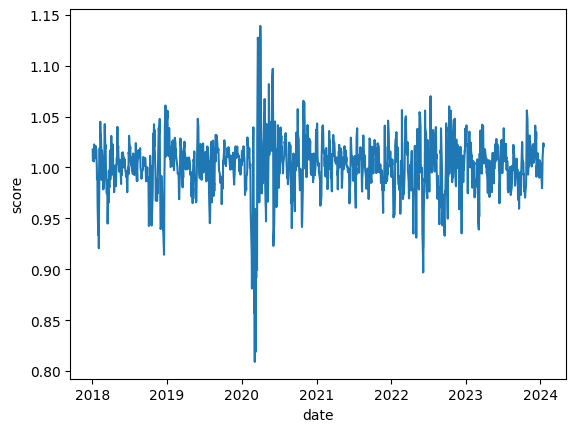

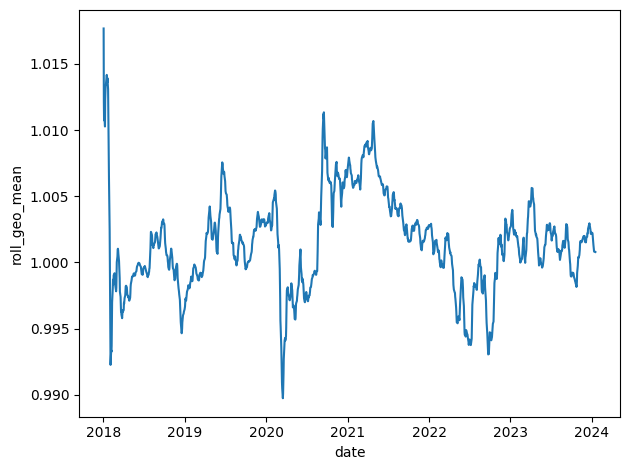

In [11]:
def exponential_moving_average(
    values: np.ndarray,
    window: int,
    alpha: float,
) -> np.ndarray:
    """
    values: (n_samples, n_timesteps)
    alpha: scalar EMA decay (0 < alpha <= 1)
    """
    values = np.asarray(values, dtype=np.float64)
    n, T = values.shape
    out = np.empty((n, T), dtype=np.float64)
    decay = 1.0 - alpha
    for t in range(T):
        start = max(0, t - window + 1)
        x = values[:, start:t + 1]  # (n, L)
        L = x.shape[1]
        w = decay ** np.arange(L - 1, -1, -1, dtype=np.float64)  # newest gets weight 1
        w /= w.sum()
        out[:, t] = x @ w        
    return out

def moving_average(
    values: np.ndarray,
    window: int,
) -> np.ndarray:
    """
    True finite-window rolling SMA (like the truncated EMA pattern).
    Uses only the last `window` points.
    Warmup uses shorter windows.
    values: (n_samples, n_timesteps)
    """
    values = np.asarray(values, dtype=np.float64)
    n, T = values.shape
    out = np.empty((n, T), dtype=np.float64)
    for t in range(T):
        start = max(0, t - window + 1)
        out[:, t] = values[:, start:t + 1].mean(axis=1)
    return out

def time_error(X_close, X_ma, wndw=10):
    nS, nT = X_close.shape
    
    rmse = np.empty(nS, dtype=float)
    
    rmse = np.sqrt(np.mean((X_close[:, -wndw:] - X_ma[:, -wndw:]) ** 2, axis=1))
    
    return rmse

def plt_results(dates, mask, y):
    y[~mask] = 1.0
    df = pl.DataFrame({
        "date": dates,
        "score": y,
    })
    df_day = df.group_by('date', maintain_order=True).agg(pl.col('score').log().mean().exp())
    df_roll = df_day.with_columns(
        roll_geo_mean = pl.col("score").rolling_mean_by(
            by="date",
            window_size="6mo",    # 6 calendar months
            min_samples=1,        # optional: require at least 1 value
            closed="right",       # (t - 6mo, t]
        )
    )
    sns.lineplot(data=df_day, x="date", y="score")
    plt.show()

    sns.lineplot(data=df_roll, x="date", y="roll_geo_mean")
    plt.tight_layout()
    plt.show()

from src.mathTools.RegimeChange import RegimeChange
Xtime_close = Xtime[:, :, timenames.index("FeatureLSTM_AdjClose")]
Xtree_close = RegimeChange.to_tree(Xtime_close, 1.0)

print(f"Shape Xtree_close: {Xtree_close.shape}")

plt_results(meta_tr.get_column("date"), np.ones(len(meta_tr), dtype=bool), ytree[:, 4])

## Ranges

debug:

Xtime_night_jump_streched and last : 1.012

Xtime_night_jump and last : 1.01 (? survivership bias)

Xtime_true_range_stretched and last : 1.01

Xtime_high_false_range_stretched and last: 1.0095

Xtime_true_range and last : 1.011 (survivership bias)

dez:



In [26]:
center = 0.5
D = np.abs(Xtime_close - center)                  # (N, T)
den = np.max(D, axis=1)                           # (N, 1)
den = np.where(den < 1e-5, 1.0, den)              # avoid div-by-zero

Xtime_close_stretched = ((Xtime_close - center) / den[:, np.newaxis])/2 + center

Xtime_open = Xtime[:, :, timenames.index("FeatureLSTM_AdjOpen")]
Xtime_high = Xtime[:, :, timenames.index("FeatureLSTM_AdjHigh")]
Xtime_low = Xtime[:, :, timenames.index("FeatureLSTM_AdjLow")]

Xtime_open_stretched = ((Xtime_open - center) / den[:, np.newaxis])/2 + center
Xtime_high_stretched = ((Xtime_high - center) / den[:, np.newaxis])/2 + center
Xtime_low_stretched = ((Xtime_low - center) / den[:, np.newaxis])/2 + center

Xtime_night_jump = Xtime_open[:, 1:] - Xtime_close[:, :-1]
Xtime_night_jump_streched = Xtime_open_stretched[:, 1:] - Xtime_close_stretched[:, :-1]

Xtime_range_stretched = np.abs(Xtime_high_stretched[:, 1:] - Xtime_low_stretched[:, 1:])
Xtime_jump_to_high_stretched = np.abs(Xtime_high_stretched[:, 1:] - Xtime_close_stretched[:, :-1])
Xtime_jump_to_low_stretched = np.abs(Xtime_low_stretched[:, 1:] - Xtime_close_stretched[:, :-1])
Xtime_true_range_stretched = np.maximum.reduce([Xtime_range_stretched, Xtime_jump_to_high_stretched, Xtime_jump_to_low_stretched])

Xtime_range = np.abs(Xtime_high[:, 1:] - Xtime_low[:, 1:])
Xtime_jump_to_high = np.abs(Xtime_high[:, 1:] - Xtime_close[:, :-1])
Xtime_jump_to_low = np.abs(Xtime_low[:, 1:] - Xtime_close[:, :-1])
Xtime_true_range = np.maximum.reduce([Xtime_range, Xtime_jump_to_high, Xtime_jump_to_low])

Xtime_retail_diff = Xtime_close_stretched[:, 1:] - Xtime_open_stretched[:, :-1]
Xtime_high_false_range_stretched = np.minimum(
    Xtime_high_stretched[:, 1:] - Xtime_open_stretched[:, :-1],
    Xtime_high_stretched[:, 1:] - Xtime_close_stretched[:, :-1],
)
Xtime_low_false_range_stretched = np.minimum(
    Xtime_open_stretched[:, :-1]  - Xtime_low_stretched[:, 1:],
    Xtime_close_stretched[:, :-1] - Xtime_low_stretched[:, 1:],
)
Xtime_false_range_streched = np.maximum(Xtime_high_false_range_stretched, Xtime_low_false_range_stretched)

Xtime_retail_diff = Xtime_close[:, 1:] - Xtime_open[:, :-1]
Xtime_high_false_range = np.minimum(
    Xtime_high[:, 1:] - Xtime_open[:, :-1],
    Xtime_high[:, 1:] - Xtime_close[:, :-1],
)
Xtime_low_false_range = np.minimum(
    Xtime_open[:, :-1]  - Xtime_low[:, 1:],
    Xtime_close[:, :-1] - Xtime_low[:, 1:],
)
Xtime_false_range = np.maximum(Xtime_high_false_range, Xtime_low_false_range)
def objective(trial):
    ma_wndw      = trial.suggest_int("ma_wndw", 1, 8, step=1) 
    
    is_expo = trial.suggest_categorical("is_expo", [True, False])
    if is_expo:
        alpha = trial.suggest_float("alpha", 0.05, 0.5)
    else:
        alpha = 1.0

    qup_fr    = trial.suggest_float("qup_fr", 0.001, 0.94)
    qdown_fr  = trial.suggest_float("qdown_fr", qup_fr+0.04, 0.999)
    qup_fr = np.clip(qup_fr, 0.001, 0.999)
    qdown_fr = np.clip(qdown_fr, 0.001, 0.999)
    
    qup_last    = trial.suggest_float("qup_last", 0.001, 0.94)
    qdown_last  = trial.suggest_float("qdown_last", qup_last+0.04, 0.999)
    qup_last = np.clip(qup_last, 0.001, 0.999)
    qdown_last = np.clip(qdown_last, 0.001, 0.999)
    
    n_clusters = trial.suggest_int("n_clusters", 50, 100, step=1)
        
    ## --- compute MA, RMSE, slope ---
    if is_expo:
        X_ma = exponential_moving_average(Xtime_night_jump_streched, ma_wndw, alpha=alpha)
    else:
        X_ma = moving_average(Xtime_night_jump_streched, ma_wndw)

    ## --- FR mask ---
    fr = X_ma[:, -1]
    thr_fr_up, thr_fr_down = np.quantile(fr, [qup_fr, qdown_fr])
    mask_fr = (fr >= thr_fr_up) & (fr <= thr_fr_down)
    
    # --- last entry mask ---
    last = Xtime_close[:, -1]/Xtime_close[:, -2]
    thr_last_up, thr_last_down = np.quantile(last, [qup_last, qdown_last])
    mask_last = (last >= thr_last_up) & (last <= thr_last_down)
    
    # --- combined mask ---
    mask_res = mask_last & mask_fr
    if sum(mask_res)/len(mask_res) < 0.005:
        return -9999.0    # not enough samples to evaluate

    # --- sl tp ---
    # robust bin edges
    vec_idx1  = Xtree[:, treenames.index("FeatureGroup_WeightedIndexMHPct_lag_m1_MH_1")]
    vec_idx2 = Xtree[:, treenames.index("MathFeature_Return_log")]
    if vec_idx1.size < 10 or vec_idx2.size < 10:
        return -9999.0  # not enough samples to evaluate

    idx_tar = 4
    #sl_mat, _, tp_mat, _ = HelperSLTP.sltp_clustered(
    #    ls.train_ytime[:, :idx_tar], 
    #    ls.train_ytree_low[:, :idx_tar], 
    #    ls.train_ytree_high[:, :idx_tar], 
    #    ls.train_ytree_open[:, :idx_tar], 
    #    Xtr_feats = np.column_stack([vec_idx1, vec_idx2]),
    #    Xte_feats = np.column_stack([vec_idx1, vec_idx2]),
    #    n_clusters = n_clusters,
    #    include_live_mask=False, # True is doing worse
    #)

    res_vec = HelperMetrics.collapse_sl_tp(
        ytree[:, :idx_tar][mask_res],
        ls.train_ytree_low[:, :idx_tar][mask_res],
        ls.train_ytree_high[:, :idx_tar][mask_res],
        ls.train_ytree_open[:, :idx_tar][mask_res],
        sl=0.8,
        tp=1.5,
    )    
    res_vec_full = np.zeros(ytree.shape[0])
    res_vec_full[mask_res] = res_vec
    #metric = HelperMetrics.evaluate_mask_mintarday(
    #    mask_res,
    #    meta_tr.get_column("date"),
    #    res_vec_full,
    #    min_targets_perday=1
    #)
    metric = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        res_vec_full,
    )
    metric_nosltp = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        ytree[:, idx_tar],
    )

    score = metric 

    trial.set_user_attr("metric", metric)
    trial.set_user_attr("metric_nosltp", metric_nosltp)
    trial.set_user_attr("mask_res", mask_res)
    trial.set_user_attr("res_vec_full", res_vec_full)

    return score

sampler = optuna.samplers.TPESampler(n_startup_trials=150)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=800)
df_fr: pd.DataFrame = study.trials_dataframe()
print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-06 09:59:27,266] A new study created in memory with name: no-name-1facb191-a1d1-4227-bd22-dd2910e531fb
[I 2026-01-06 09:59:27,746] Trial 0 finished with value: 1.001792988775271 and parameters: {'ma_wndw': 2, 'is_expo': False, 'qup_fr': 0.2881539588916393, 'qdown_fr': 0.40323266308527317, 'qup_last': 0.2761293850869104, 'qdown_last': 0.7882189681856554, 'n_clusters': 70}. Best is trial 0 with value: 1.001792988775271.
[I 2026-01-06 09:59:28,007] Trial 1 finished with value: 1.0002295840369506 and parameters: {'ma_wndw': 1, 'is_expo': True, 'alpha': 0.14932570197103373, 'qup_fr': 0.20962088949821825, 'qdown_fr': 0.5408263419239293, 'qup_last': 0.8781342949968183, 'qdown_last': 0.9440507544453709, 'n_clusters': 90}. Best is trial 0 with value: 1.001792988775271.
[I 2026-01-06 09:59:28,291] Trial 2 finished with value: 0.9991385622666324 and parameters: {'ma_wndw': 6, 'is_expo': True, 'alpha': 0.11668591329153707, 'qup_fr': 0.6307453791505985, 'qdown_fr': 0.7323931325370237, 'q

Best value: 1.0058387717520876
Best params: {'ma_wndw': 5, 'is_expo': True, 'alpha': 0.26848948610907963, 'qup_fr': 0.26374476673671354, 'qdown_fr': 0.3884669579528957, 'qup_last': 0.8664736652167954, 'qdown_last': 0.9226183217057656, 'n_clusters': 66}


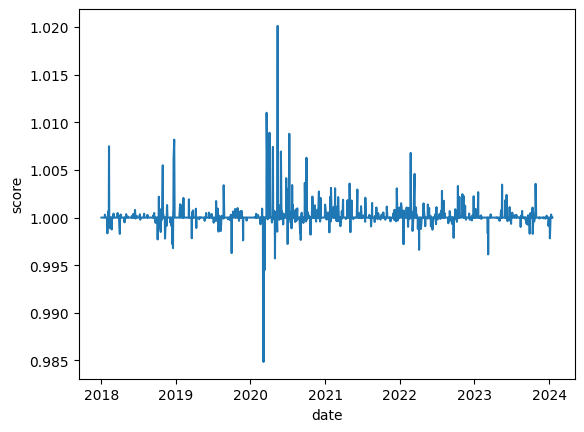

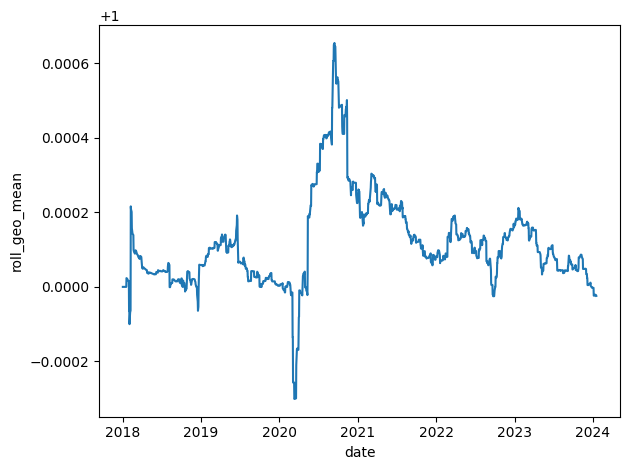

Selected tickers (90): ['NKE', 'AMKR', 'CSCO', 'CAH', 'UNH', 'C', 'WFC', 'T', 'K', 'BAC', 'PPL', 'VZ', 'ADSK', 'MCD', 'MU', 'EA', 'DIS', 'CNC', 'SBUX', 'TFC', 'KEY', 'MS', 'MGM', 'ADP', 'HPQ', 'GEN', 'TXN', 'MA', 'CMS', 'AMD', 'LLY', 'CVX', 'DVN', 'XEL', 'CTSH', 'SLB', 'KMB', 'INTC', 'NEE', 'DAL', 'USB', 'ORCL', 'WHR', 'UNP', 'MDLZ', 'XOM', 'MO', 'PFE', 'JNJ', 'GIS', 'CSX', 'OXY', 'LUV', 'IP', 'LRCX', 'LKQ', 'GOOGL', 'TSCO', 'BLK', 'KO', 'QCOM', 'HOLX', 'RTX', 'MSTR', 'MSFT', 'HBAN', 'GS', 'CMCSA', 'NFLX', 'WEC', 'EBAY', 'WMT', 'ICE', 'BEN', 'ADBE', 'UPS', 'AMZN', 'TSN', 'WTRG', 'MDT', 'NI', 'BWA', 'RF', 'APA', 'HAL', 'NVDA', 'REGN', 'AAPL', 'BA', 'CRM']


In [12]:
best = study.best_trial
best_score = best.value
mask_res = best.user_attrs["mask_res"]
res_vec_full = best.user_attrs["res_vec_full"]
dates = meta_tr.get_column("date")
    
plt_results(dates, mask_res, res_vec_full)

tickers = meta_tr.get_column("ticker").filter(mask_res).unique().to_list()
print(f"Selected tickers ({len(tickers)}): {tickers}")

## tunneling (again)  
I got something like 1.008 (debug)

In [46]:
center = 0.5
D = np.abs(Xtime_close - center)                            # (N, T)
den = np.max(D, axis=1)                # (N, 1)
den = np.where(den < 1e-5, 1.0, den)              # avoid div-by-zero

Xtime_close_stretched = ((Xtime_close - center) / den[:, np.newaxis])/2 + center
def objective(trial):
    ma_wndw    = trial.suggest_int("ma_wndw", 1, 30, step=1) 
    rsme_wndw  = trial.suggest_int("rsme_wndw", 1, 30, step=1)
    tunnel_delay = trial.suggest_int("tunnel_delay", 1, 8, step=1)
    end_wndw = trial.suggest_int("end_wndw", 1, 30, step=1)
    
    is_expo = trial.suggest_categorical("is_expo", [True, False])
    if is_expo:
        alpha = trial.suggest_float("alpha", 0.05, 0.3)
    else:
        alpha = 1.0

    qup_rmse    = trial.suggest_float("qup_rmse", 0.001, 0.94)
    qdown_rmse  = trial.suggest_float("qdown_rmse", qup_rmse+0.04, 0.999)
    
    #qup_slope   = trial.suggest_float("qup_slope", 0.001, 0.94)
    #qdown_slope = trial.suggest_float("qdown_slope", qup_slope+0.04, 0.999)
    
    qup_last = trial.suggest_float("qup_last", 0.001, 0.94)
    qdown_last = trial.suggest_float("qdown_last", qup_last+0.04, 0.999)
    
    qup_rmse    = np.clip(qup_rmse, 0.0, 0.999)
    qdown_rmse  = np.clip(qdown_rmse, 0.0, 0.999)
    #qup_slope   = np.clip(qup_slope, 0.0, 0.999)
    #qdown_slope = np.clip(qdown_slope, 0.0, 0.999)
    qup_last    = np.clip(qup_last, 0.0, 0.999)
    qdown_last  = np.clip(qdown_last, 0.0, 0.999)

    # --- compute MA, RMSE, slope ---
    if is_expo:
        X_ma = exponential_moving_average(Xtime_close_stretched, ma_wndw, alpha=alpha)
    else:
        X_ma = moving_average(Xtime_close_stretched, ma_wndw)
    rmse = time_error(Xtime_close_stretched[:, :-tunnel_delay], X_ma[:, :-tunnel_delay], wndw=rsme_wndw)               # shape (nS,)
    #slope = np.mean(np.diff(Xtime_close_stretched[:, -end_wndw:], axis=1),axis=1)  # shape (nS,)

    # --- RMSE mask ---
    thr_rmse_up, thr_rmse_down = np.quantile(rmse, [qup_rmse, qdown_rmse])
    mask_rmse = (rmse >= thr_rmse_up) & (rmse <= thr_rmse_down)
    
    # --- slope mask ---
    #thr_slope_up, thr_slope_down = np.quantile(slope, [qup_slope, qdown_slope])
    #mask_slope = (slope >= thr_slope_up) & (slope <= thr_slope_down)
    
    # --- last entry mask ---
    last = Xtime_close[:, -1]/Xtime_close[:, -2]
    thr_last_up, thr_last_down = np.quantile(last, [qup_last, qdown_last])
    mask_last = (last >= thr_last_up) & (last <= thr_last_down)

    # --- combined mask ---
    mask_res = mask_rmse & mask_last #& mask_slope
    if sum(mask_res)/len(mask_res) < 0.05:
        return -9999.0    # not enough samples to evaluate

    # --- sl tp ---
    # robust bin edges
    vec_idx  = Xtree[:, treenames.index("FeatureGroup_WeightedIndexMHPct_lag_m1_MH_1")][mask_res]
    vec_drop = last[mask_res]
    if vec_idx.size < 10 or vec_drop.size < 10:
        return -9999.0  # not enough samples to evaluate

    vol_q1, vol_q2 = np.quantile(vec_drop, [1/3, 2/3])
    idx_q1, idx_q2 = np.quantile(vec_idx,  [1/3, 2/3])

    vol_bin = np.digitize(vec_drop, [vol_q1, vol_q2])  # 0,1,2
    idx_bin = np.digitize(vec_idx,  [idx_q1, idx_q2])  # 0,1,2

    # --- SL grid (as you already have) ---
    sl00 = trial.suggest_float("sl00", 0.75, 0.995)
    sl01 = trial.suggest_float("sl01", 0.75, 0.995)
    sl02 = trial.suggest_float("sl02", 0.75, 0.995)
    sl10 = trial.suggest_float("sl10", 0.75, 0.995)
    sl11 = trial.suggest_float("sl11", 0.75, 0.995)
    sl12 = trial.suggest_float("sl12", 0.75, 0.995)
    sl20 = trial.suggest_float("sl20", 0.75, 0.995)
    sl21 = trial.suggest_float("sl21", 0.75, 0.995)
    sl22 = trial.suggest_float("sl22", 0.75, 0.995)

    sl_grid = np.array([[sl00, sl01, sl02],
                        [sl10, sl11, sl12],
                        [sl20, sl21, sl22]], dtype=float)

    sl_vec = sl_grid[vol_bin, idx_bin]
    sl_vec = np.clip(sl_vec, 0.60, 0.999)

    # --- TP grid (new) ---
    tp00 = trial.suggest_float("tp00", 1.005, 2.0)
    tp01 = trial.suggest_float("tp01", 1.005, 2.0)
    tp02 = trial.suggest_float("tp02", 1.005, 2.0)
    tp10 = trial.suggest_float("tp10", 1.005, 2.0)
    tp11 = trial.suggest_float("tp11", 1.005, 2.0)
    tp12 = trial.suggest_float("tp12", 1.005, 2.0)
    tp20 = trial.suggest_float("tp20", 1.005, 2.0)
    tp21 = trial.suggest_float("tp21", 1.005, 2.0)
    tp22 = trial.suggest_float("tp22", 1.005, 2.0)

    tp_grid = np.array([[tp00, tp01, tp02],
                        [tp10, tp11, tp12],
                        [tp20, tp21, tp22]], dtype=float)

    tp_vec = tp_grid[vol_bin, idx_bin]
    tp_vec = np.clip(tp_vec, 1.005, 2.0)

    idx_tar = 4
    res_vec = HelperMetrics.collapse_sl_tp(
        ytree[:, idx_tar][mask_res],
        ls.train_ytree_low[:, idx_tar][mask_res],
        ls.train_ytree_high[:, idx_tar][mask_res],
        ls.train_ytree_open[:, idx_tar][mask_res],
        sl=sl_vec,
        tp=tp_vec,
    )    
    res_vec_full = np.zeros(ytree.shape[0])
    res_vec_full[mask_res] = res_vec
    #metric = HelperMetrics.evaluate_mask_mintarday(
    #    mask_res,
    #    meta_tr.get_column("date"),
    #    res_vec_full,
    #    min_targets_perday=1
    #)
    metric = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        res_vec_full,
    )
    metric_nosltp = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        ytree[:, idx_tar],
    )

    score = metric 

    trial.set_user_attr("metric", metric)
    trial.set_user_attr("metric_nosltp", metric_nosltp)
    trial.set_user_attr("mask_res", mask_res)
    trial.set_user_attr("res_vec_full", res_vec_full)

    return score

sampler = optuna.samplers.TPESampler(n_startup_trials=100)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=700)
df_tunneling: pd.DataFrame = study.trials_dataframe()
print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-22 12:51:12,837] A new study created in memory with name: no-name-c3be5edb-70de-42ee-a7ac-a561530e1f93
[I 2025-12-22 12:51:13,211] Trial 0 finished with value: -9999.0 and parameters: {'ma_wndw': 29, 'rsme_wndw': 10, 'tunnel_delay': 3, 'end_wndw': 29, 'is_expo': True, 'alpha': 0.19363196726185078, 'qup_rmse': 0.3969026113508695, 'qdown_rmse': 0.5979627689369711, 'qup_last': 0.5521421356914871, 'qdown_last': 0.6822124839489798}. Best is trial 0 with value: -9999.0.
[I 2025-12-22 12:51:13,734] Trial 1 finished with value: -9999.0 and parameters: {'ma_wndw': 29, 'rsme_wndw': 13, 'tunnel_delay': 6, 'end_wndw': 20, 'is_expo': False, 'qup_rmse': 0.5807608400042369, 'qdown_rmse': 0.681581496574562, 'qup_last': 0.919637932722264, 'qdown_last': 0.9798244702699435}. Best is trial 0 with value: -9999.0.
[I 2025-12-22 12:51:14,262] Trial 2 finished with value: 1.0025590726015812 and parameters: {'ma_wndw': 13, 'rsme_wndw': 12, 'tunnel_delay': 2, 'end_wndw': 21, 'is_expo': False, 'qup_rm

Best value: 1.0045342765201015
Best params: {'ma_wndw': 27, 'rsme_wndw': 10, 'tunnel_delay': 1, 'end_wndw': 1, 'is_expo': False, 'qup_rmse': 0.5114042003467631, 'qdown_rmse': 0.9318727860570202, 'qup_last': 0.1955609944452008, 'qdown_last': 0.3616123741297588, 'sl00': 0.8132475989524787, 'sl01': 0.9300111910800378, 'sl02': 0.7536174128312518, 'sl10': 0.9223187761837932, 'sl11': 0.8750347466247596, 'sl12': 0.8762947097930759, 'sl20': 0.7602711464988758, 'sl21': 0.7646592718496111, 'sl22': 0.7556336605507382, 'tp00': 1.052746516712048, 'tp01': 1.4665093103612812, 'tp02': 1.436268072729611, 'tp10': 1.96990042754696, 'tp11': 1.9524765401408177, 'tp12': 1.704606983323595, 'tp20': 1.4626697161442348, 'tp21': 1.455693946554306, 'tp22': 1.4775062512911095}


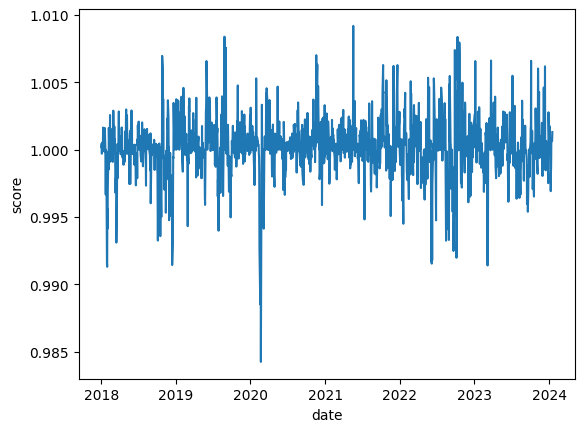

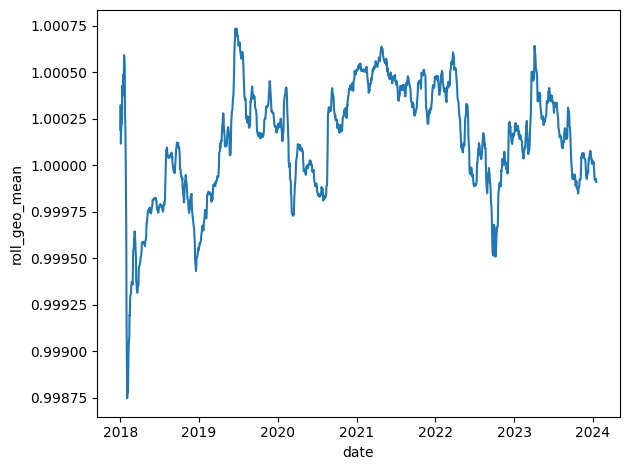

In [47]:
best = study.best_trial
best_score = best.value
mask_res = best.user_attrs["mask_res"]
res_vec_full = best.user_attrs["res_vec_full"]
dates = meta_tr.get_column("date")
    
plt_results(dates, mask_res, res_vec_full)

## triple drop and SL
someting like 1.0093

In [51]:

import optuna

Xtree_return = Xtree_close[:, 1:] / Xtree_close[:, :-1]
Xtree_return_last = Xtree_return[:, -1]

def objective(trial):
    ma_wndw      = 1 #trial.suggest_int("ma_wndw", 1, 25, step=1)
    
    qup_retdrop   = trial.suggest_float("qup_retdrop", 0.001, 0.05)
    qdown_retdrop = trial.suggest_float("qdown_retdrop", qup_retdrop+0.021, 0.15)
    qup_retdrop = np.clip(qup_retdrop, 0.0, 1.0)
    qdown_retdrop = np.clip(qdown_retdrop, 0.0, 1.0)
    
    is_expo = False #trial.suggest_categorical("is_expo", [True, False])
    if is_expo:
        alpha = trial.suggest_float("alpha", 0.01, 0.35)

    # --- compute ---
    if is_expo:
        X_ma = exponential_moving_average(Xtree_return, ma_wndw, alpha=alpha)
    else:
        X_ma = moving_average(Xtree_return, ma_wndw)
        
    last = Xtime_close[:, -1]/Xtime_close[:, -2]
        
    # --- Drop mask ---
    ma_last = X_ma[:, -1] 
    n_dropped = 2 #trial.suggest_int("n_dropped", 1, 2, step=1)
    mask_drop = np.all(Xtree_return[:, -n_dropped:] <= 1.0, axis=1)
    thr_last_up, thr_last_down = np.quantile(ma_last, [qup_retdrop, qdown_retdrop])
    mask_last = (ma_last >= thr_last_up) & (ma_last <= thr_last_down)
    
    mask_res = mask_last & mask_drop
    
    # --- sl tp ---
    # robust bin edges
    vec_idx  = Xtree[:, treenames.index("FeatureGroup_WeightedIndexMHPct_lag_m1_MH_1")][mask_res]
    vec_drop = last[mask_res]
    if vec_idx.size < 10 or vec_drop.size < 10:
        return -9999.0  # not enough samples to evaluate

    vol_q1, vol_q2 = np.quantile(vec_drop, [1/3, 2/3])
    idx_q1, idx_q2 = np.quantile(vec_idx,  [1/3, 2/3])

    vol_bin = np.digitize(vec_drop, [vol_q1, vol_q2])  # 0,1,2
    idx_bin = np.digitize(vec_idx,  [idx_q1, idx_q2])  # 0,1,2

    # --- SL grid (as you already have) ---
    sl00 = trial.suggest_float("sl00", 0.75, 0.995)
    sl01 = trial.suggest_float("sl01", 0.75, 0.995)
    sl02 = trial.suggest_float("sl02", 0.75, 0.995)
    sl10 = trial.suggest_float("sl10", 0.75, 0.995)
    sl11 = trial.suggest_float("sl11", 0.75, 0.995)
    sl12 = trial.suggest_float("sl12", 0.75, 0.995)
    sl20 = trial.suggest_float("sl20", 0.75, 0.995)
    sl21 = trial.suggest_float("sl21", 0.75, 0.995)
    sl22 = trial.suggest_float("sl22", 0.75, 0.995)

    sl_grid = np.array([[sl00, sl01, sl02],
                        [sl10, sl11, sl12],
                        [sl20, sl21, sl22]], dtype=float)

    sl_vec = sl_grid[vol_bin, idx_bin]
    sl_vec = np.clip(sl_vec, 0.60, 0.999)

    # --- TP grid (new) ---
    tp00 = trial.suggest_float("tp00", 1.005, 2.0)
    tp01 = trial.suggest_float("tp01", 1.005, 2.0)
    tp02 = trial.suggest_float("tp02", 1.005, 2.0)
    tp10 = trial.suggest_float("tp10", 1.005, 2.0)
    tp11 = trial.suggest_float("tp11", 1.005, 2.0)
    tp12 = trial.suggest_float("tp12", 1.005, 2.0)
    tp20 = trial.suggest_float("tp20", 1.005, 2.0)
    tp21 = trial.suggest_float("tp21", 1.005, 2.0)
    tp22 = trial.suggest_float("tp22", 1.005, 2.0)

    tp_grid = np.array([[tp00, tp01, tp02],
                        [tp10, tp11, tp12],
                        [tp20, tp21, tp22]], dtype=float)

    tp_vec = tp_grid[vol_bin, idx_bin]
    tp_vec = np.clip(tp_vec, 1.005, 2.0)

    idx_tar = 4
    res_vec = HelperMetrics.collapse_sl_tp(
        ytree[:, idx_tar][mask_res],
        ls.train_ytree_low[:, idx_tar][mask_res],
        ls.train_ytree_high[:, idx_tar][mask_res],
        ls.train_ytree_open[:, idx_tar][mask_res],
        sl=sl_vec,
        tp=tp_vec,
    )    
    res_vec_full = np.zeros(ytree.shape[0])
    res_vec_full[mask_res] = res_vec
    #metric = HelperMetrics.evaluate_mask_mintarday(
    #    mask_res,
    #    meta_tr.get_column("date"),
    #    res_vec_full,
    #    min_targets_perday=1
    #)
    metric = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        res_vec_full,
    )
    metric_nosltp = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        ytree[:, idx_tar],
    )

    score = metric 

    trial.set_user_attr("metric", metric)
    trial.set_user_attr("metric_nosltp", metric_nosltp)
    trial.set_user_attr("mask_res", mask_res)
    trial.set_user_attr("res_vec_full", res_vec_full)

    return score

sampler = optuna.samplers.TPESampler(n_startup_trials=100)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=1000)
df_drop: pd.DataFrame = study.trials_dataframe()
print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-22 13:55:22,494] A new study created in memory with name: no-name-498dfc90-966b-4406-a613-0aad60c3f2df
[I 2025-12-22 13:55:22,769] Trial 0 finished with value: 1.001795310979735 and parameters: {'qup_retdrop': 0.021843816703640526, 'qdown_retdrop': 0.13585483446858432, 'sl00': 0.8043935330611913, 'sl01': 0.9396140989424908, 'sl02': 0.8041595349241324, 'sl10': 0.7847451810361629, 'sl11': 0.8254941494524126, 'sl12': 0.9266594473603995, 'sl20': 0.7713704045908836, 'sl21': 0.9500030660113381, 'sl22': 0.8508350339849016, 'tp00': 1.9268307605213741, 'tp01': 1.756127244147157, 'tp02': 1.0345704676550076, 'tp10': 1.145121131670502, 'tp11': 1.95750011940167, 'tp12': 1.118582402357773, 'tp20': 1.2034775738810244, 'tp21': 1.7933767856466283, 'tp22': 1.6084688432361829}. Best is trial 0 with value: 1.001795310979735.
[I 2025-12-22 13:55:23,008] Trial 1 finished with value: 1.0031104928816272 and parameters: {'qup_retdrop': 0.03566774201222263, 'qdown_retdrop': 0.11354332933489558, 'sl00

Best value: 1.0087988974267155
Best params: {'qup_retdrop': 0.037046491442981645, 'qdown_retdrop': 0.061002525972547975, 'sl00': 0.760230148739876, 'sl01': 0.8220077973839938, 'sl02': 0.9004399805348229, 'sl10': 0.7727316206096849, 'sl11': 0.9904686844912953, 'sl12': 0.7720683663403647, 'sl20': 0.772117014640055, 'sl21': 0.8644619405672872, 'sl22': 0.9032422187920027, 'tp00': 1.4644864466662102, 'tp01': 1.6008447401298196, 'tp02': 1.040360481726087, 'tp10': 1.5440306807012352, 'tp11': 1.0887975062229198, 'tp12': 1.9377468249398504, 'tp20': 1.9890271167569733, 'tp21': 1.5474853864613696, 'tp22': 1.9162123495305685}


In [52]:
imp = optuna.importance.get_param_importances(study)
for key, value in imp.items():
    logger.info("%s: %s", key, value)

qup_retdrop: 0.8069288003905039
sl12: 0.026880986241474603
sl00: 0.022785865248151838
tp02: 0.01707452797347353
sl11: 0.014290289571822328
sl10: 0.012963849008296283
sl02: 0.011775005843273808
tp22: 0.010779977069607287
sl21: 0.010149190397903168
tp20: 0.009877264275836333
tp10: 0.009609535593620034
tp00: 0.009037277626297918
tp21: 0.008810328713540792
sl01: 0.007761717175335804
sl22: 0.006755762081845476
tp11: 0.005410034998055875
tp01: 0.004391160277620386
sl20: 0.0025153605728172614
tp12: 0.002203066940523557


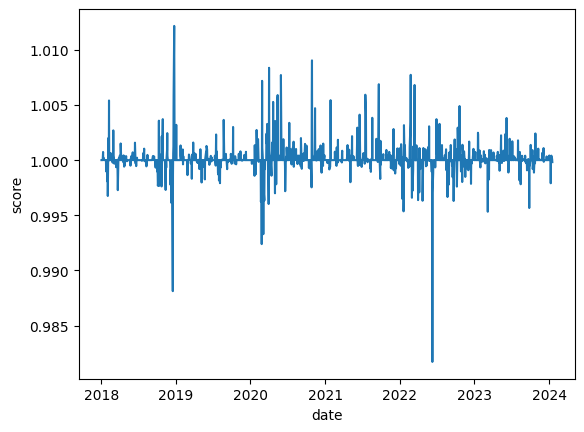

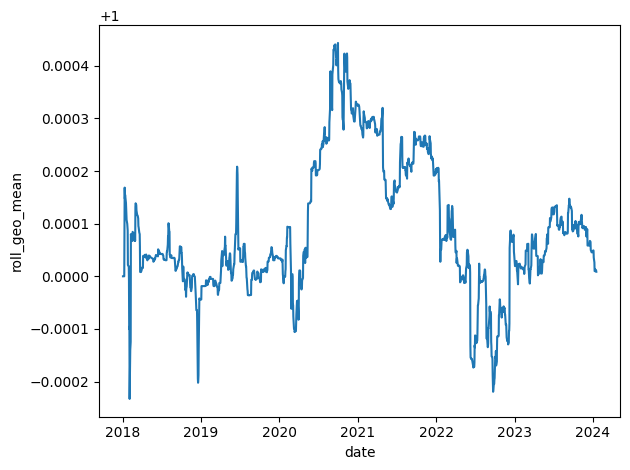

In [53]:
best = study.best_trial
best_score = best.value
mask_res = best.user_attrs["mask_res"]
res_vec_full = best.user_attrs["res_vec_full"]
dates = meta_tr.get_column("date")
    
plt_results(dates, mask_res, res_vec_full)

# ATR (again)
something like 1.01

In [71]:
import optuna

def objective(trial):
    ma_wndw    = trial.suggest_int("ma_wndw", 1, 10, step=1) 
    slope_wndw   = trial.suggest_int("slope_wndw", 1, 22, step=1)

    qup_atr    = trial.suggest_float("qup_atr", 0.1, 0.96)
    qdown_atr  = trial.suggest_float("qdown_atr", qup_atr+0.03, 0.999)
    qup_atr = np.clip(qup_atr, 0.0, 0.999)
    qdown_atr = np.clip(qdown_atr, 0.0, 0.999)
    q_len = qdown_atr - qup_atr
    
    q_slope_len = 0.01/q_len
    qup_slope   = trial.suggest_float("qup_slope", 0.0, 1.0 - q_slope_len - 0.01)
    qdown_slope = trial.suggest_float("qdown_slope", qup_slope+q_slope_len, 0.999)
    qup_slope = np.clip(qup_slope, 0.0, 0.999)
    qdown_slope = np.clip(qdown_slope, 0.0, 0.999)
    
    if qup_slope >= qdown_slope:
        qup_slope, qdown_slope = qdown_slope, qup_slope
        
    if qup_atr >= qdown_atr:
        qup_atr, qdown_atr = qdown_atr, qup_atr
    
    #qup_sit = trial.suggest_float("qup_sit", 0.0, 0.92)
    #qdown_sit = trial.suggest_float("qdown_sit", qup_sit+0.05, 0.999)
    #qup_sit = np.clip(qup_sit, 0.0, 0.999)
    #qdown_sit = np.clip(qdown_sit, 0.0, 0.999)
    
    #rsme_wndw  = trial.suggest_int("rsme_wndw", 4, 40, step=1)
    #tunnel_delay = trial.suggest_int("tunnel_delay", 1, 6, step=1)
    
    is_expo = False # trial.suggest_categorical("is_expo", [True, False])

    #qup_rmse    = trial.suggest_float("qup_rmse", 0.1, 0.9)
    #qdown_rmse  = 0.998 #trial.suggest_float("qdown_rmse", 0.98, 0.999)

    # --- compute MA, RMSE, slope ---
    if is_expo:
        X_ma = exponential_moving_average(Xtree_close, ma_wndw)
    else:
        X_ma = moving_average(Xtree_close, ma_wndw)

    # --- RMSE mask ---
    #rmse = time_error(Xtree_close[:, :-tunnel_delay], X_ma[:, :-tunnel_delay], wndw=rsme_wndw)               # shape (nS,)
    #thr_rmse_up, thr_rmse_down = np.quantile(rmse, [qup_rmse, qdown_rmse])
    #mask_rmse = (rmse >= thr_rmse_up) & (rmse <= thr_rmse_down)

    # --- atr mask ---
    idx_atr = treenames.index("FeatureTA_volatility_atr")
    atr = Xtree[:, idx_atr]
    thr_atr_up, thr_atr_down = np.quantile(atr, [qup_atr, qdown_atr])
    mask_atr = (atr >= thr_atr_up) & (atr <= thr_atr_down)
    
    # --- slope mask ---
    slope = np.mean(np.diff(Xtree_close[mask_atr][:, -slope_wndw:], axis=1),axis=1)  # shape (nS,)
    thr_slope_up, thr_slope_down = np.quantile(slope, [qup_slope, qdown_slope])
    mask_slope = (slope >= thr_slope_up) & (slope <= thr_slope_down)

    # --- combined mask ---
    mask_res = mask_atr #& mask_slope & mask_rmse
    mask_res[mask_atr] = mask_slope
    
    if np.sum(mask_res) / len(mask_res) < 0.01:
        return -9999.0

    # --- sl tp ---
    # robust bin edges
    vec_idx  = Xtree[:, treenames.index("FeatureGroup_WeightedIndexMHPct_lag_m1_MH_1")][mask_atr]
    vec_drop = atr[mask_atr]
    if vec_idx.size < 10 or vec_drop.size < 10:
        return -9999.0  # not enough samples to evaluate

    vol_q1, vol_q2 = np.quantile(vec_drop, [1/3, 2/3])
    idx_q1, idx_q2 = np.quantile(vec_idx,  [1/3, 2/3])

    vol_bin = np.digitize(vec_drop, [vol_q1, vol_q2])  # 0,1,2
    idx_bin = np.digitize(vec_idx,  [idx_q1, idx_q2])  # 0,1,2

    # --- SL grid (as you already have) ---
    sl00 = trial.suggest_float("sl00", 0.75, 0.995)
    sl01 = trial.suggest_float("sl01", 0.75, 0.995)
    sl02 = trial.suggest_float("sl02", 0.75, 0.995)
    sl10 = trial.suggest_float("sl10", 0.75, 0.995)
    sl11 = trial.suggest_float("sl11", 0.75, 0.995)
    sl12 = trial.suggest_float("sl12", 0.75, 0.995)
    sl20 = trial.suggest_float("sl20", 0.75, 0.995)
    sl21 = trial.suggest_float("sl21", 0.75, 0.995)
    sl22 = trial.suggest_float("sl22", 0.75, 0.995)

    sl_grid = np.array([[sl00, sl01, sl02],
                        [sl10, sl11, sl12],
                        [sl20, sl21, sl22]], dtype=float)

    sl_vec = sl_grid[vol_bin, idx_bin]
    sl_vec = np.clip(sl_vec, 0.60, 0.999)

    # --- TP grid (new) ---
    tp00 = trial.suggest_float("tp00", 1.005, 2.0)
    tp01 = trial.suggest_float("tp01", 1.005, 2.0)
    tp02 = trial.suggest_float("tp02", 1.005, 2.0)
    tp10 = trial.suggest_float("tp10", 1.005, 2.0)
    tp11 = trial.suggest_float("tp11", 1.005, 2.0)
    tp12 = trial.suggest_float("tp12", 1.005, 2.0)
    tp20 = trial.suggest_float("tp20", 1.005, 2.0)
    tp21 = trial.suggest_float("tp21", 1.005, 2.0)
    tp22 = trial.suggest_float("tp22", 1.005, 2.0)

    tp_grid = np.array([[tp00, tp01, tp02],
                        [tp10, tp11, tp12],
                        [tp20, tp21, tp22]], dtype=float)

    tp_vec = tp_grid[vol_bin, idx_bin]
    tp_vec = np.clip(tp_vec, 1.005, 2.0)

    idx_tar = 4
    res_vec = HelperMetrics.collapse_sl_tp(
        ytree[:, idx_tar][mask_res],
        ls.train_ytree_low[:, idx_tar][mask_res],
        ls.train_ytree_high[:, idx_tar][mask_res],
        ls.train_ytree_open[:, idx_tar][mask_res],
        sl=sl_vec,
        tp=tp_vec,
    )    
    res_vec_full = np.zeros(ytree.shape[0])
    res_vec_full[mask_res] = res_vec
    #metric = HelperMetrics.evaluate_mask_mintarday(
    #    mask_res,
    #    meta_tr.get_column("date"),
    #    res_vec_full,
    #    min_targets_perday=1
    #)
    metric = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        res_vec_full,
    )
    metric_nosltp = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        ytree[:, idx_tar],
    )

    score = metric 

    trial.set_user_attr("metric", metric)
    trial.set_user_attr("metric_nosltp", metric_nosltp)
    trial.set_user_attr("mask_res", mask_res)
    trial.set_user_attr("res_vec_full", res_vec_full)
    trial.set_user_attr("mask_res_sum", np.sum(mask_res))
    trial.set_user_attr("mask_res_rat", np.sum(mask_res)/len(mask_res))

    return score

sampler = optuna.samplers.TPESampler(n_startup_trials=150)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=800)
df_atr: pd.DataFrame = study.trials_dataframe()
print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-22 18:56:48,151] A new study created in memory with name: no-name-44cf7fcd-dbd5-448a-a4b2-53bae98ccdd5
[I 2025-12-22 18:56:48,744] Trial 0 finished with value: 0.9989781899522827 and parameters: {'ma_wndw': 3, 'slope_wndw': 3, 'qup_atr': 0.17377770092580258, 'qdown_atr': 0.35888260256909377, 'qup_slope': 0.9279599012429054, 'qdown_slope': 0.9923154402558162, 'sl00': 0.9354351266656183, 'sl01': 0.7615491633552106, 'sl02': 0.7520001296847667, 'sl10': 0.9798946696318116, 'sl11': 0.9940900232309544, 'sl12': 0.8615904320022398, 'sl20': 0.8382643560783736, 'sl21': 0.758213201664104, 'sl22': 0.9454238521230214, 'tp00': 1.5264074799756284, 'tp01': 1.9968554165445433, 'tp02': 1.11349097315128, 'tp10': 1.9975925922419067, 'tp11': 1.2460395154172446, 'tp12': 1.41302718366873, 'tp20': 1.2603363659262072, 'tp21': 1.8905716548876028, 'tp22': 1.7801121503841402}. Best is trial 0 with value: 0.9989781899522827.
[I 2025-12-22 18:56:48,985] Trial 1 finished with value: 1.0000994341863558 and 

Best value: 1.0111394207403241
Best params: {'ma_wndw': 4, 'slope_wndw': 10, 'qup_atr': 0.869774032606562, 'qdown_atr': 0.9465604371178903, 'qup_slope': 0.5720009047371075, 'qdown_slope': 0.7712086155229481, 'sl00': 0.8881264800377561, 'sl01': 0.8683677083368876, 'sl02': 0.9001825621720941, 'sl10': 0.9825279405115166, 'sl11': 0.7883909847301025, 'sl12': 0.9195853209823499, 'sl20': 0.8438012838330284, 'sl21': 0.8590246558640907, 'sl22': 0.9939451245360335, 'tp00': 1.4105202078804402, 'tp01': 1.7763411698096774, 'tp02': 1.2624767436822337, 'tp10': 1.8728585176305732, 'tp11': 1.806852061111096, 'tp12': 1.129946103989454, 'tp20': 1.9915794066640005, 'tp21': 1.1388018308836896, 'tp22': 1.1172837824371744}


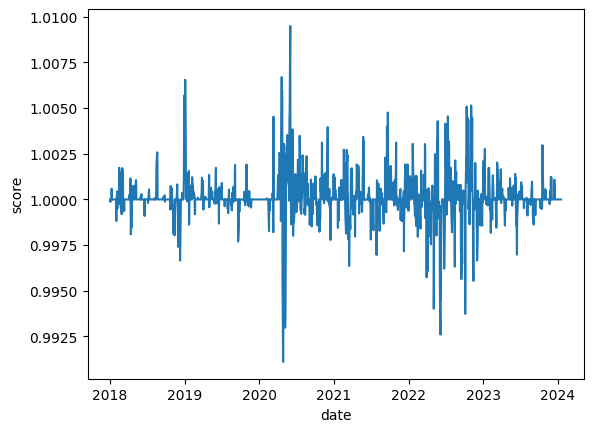

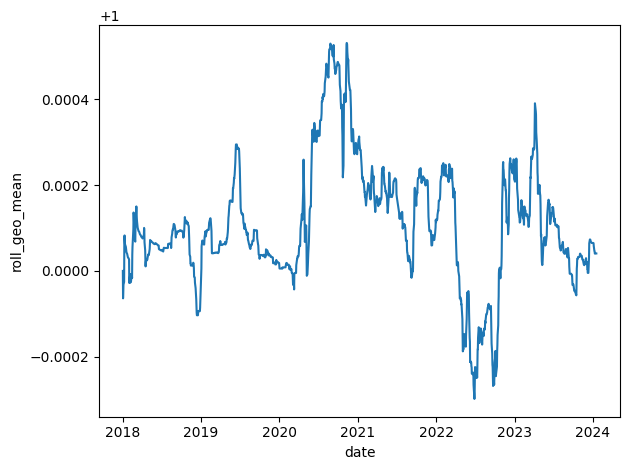

In [72]:
best = study.best_trial
best_score = best.value
mask_res = best.user_attrs["mask_res"]
res_vec_full = best.user_attrs["res_vec_full"]
dates = meta_tr.get_column("date")
    
plt_results(dates, mask_res, res_vec_full)

# trivial

In [74]:
import optuna

def objective(trial):
    ma_wndw      = trial.suggest_int("ma_wndw", 1, 10, step=1)
    slope_wndw   = trial.suggest_int("slope_wndw", 1, 22, step=1)

    qup_slope   = trial.suggest_float("qup_slope", 0.0, 0.9)
    qdown_slope = trial.suggest_float("qdown_slope", qup_slope+0.01, 0.999)
    qup_slope = np.clip(qup_slope, 0.0, 0.999)
    qdown_slope = np.clip(qdown_slope, 0.0, 0.999)
    
    qup_maend   = trial.suggest_float("qup_maend", 0.0, 0.9)
    qdown_maend = trial.suggest_float("qdown_maend", qup_maend+0.01, 0.999)
    qup_maend = np.clip(qup_maend, 0.0, 0.999)
    qdown_maend = np.clip(qdown_maend, 0.0, 0.999)
    
    if qup_slope >= qdown_slope:
        qup_slope, qdown_slope = qdown_slope, qup_slope
        
    if qup_maend >= qdown_maend:
        qup_maend, qdown_maend = qdown_maend, qup_maend
        
    # --- ma end mask ---
    X_ma = moving_average(Xtree_close, ma_wndw)
    thr_maend_up, thr_maend_down = np.quantile(X_ma[:, -1], [qup_maend, qdown_maend])
    mask_maend = (X_ma[:, -1] >= thr_maend_up) & (X_ma[:, -1] <= thr_maend_down)
    
    # --- slope mask ---
    slope = np.mean(np.diff(Xtree_close[:, -slope_wndw:], axis=1),axis=1)  # shape (nS,)
    thr_slope_up, thr_slope_down = np.quantile(slope, [qup_slope, qdown_slope])
    mask_slope = (slope >= thr_slope_up) & (slope <= thr_slope_down)

    # --- combined mask ---
    mask_res = mask_slope & mask_maend
    
    if np.sum(mask_res) / len(mask_res) < 0.01:
        return -9999.0

    # --- sl tp ---
    # robust bin edges
    vec_idx  = Xtree[:, treenames.index("FeatureGroup_WeightedIndexMHPct_lag_m1_MH_1")][mask_res]
    vec_drop = slope[mask_res]
    if vec_idx.size < 10 or vec_drop.size < 10:
        return -9999.0  # not enough samples to evaluate

    vol_q1, vol_q2 = np.quantile(vec_drop, [1/3, 2/3])
    idx_q1, idx_q2 = np.quantile(vec_idx,  [1/3, 2/3])

    vol_bin = np.digitize(vec_drop, [vol_q1, vol_q2])  # 0,1,2
    idx_bin = np.digitize(vec_idx,  [idx_q1, idx_q2])  # 0,1,2

    # --- SL grid (as you already have) ---
    sl00 = trial.suggest_float("sl00", 0.75, 0.995)
    sl01 = trial.suggest_float("sl01", 0.75, 0.995)
    sl02 = trial.suggest_float("sl02", 0.75, 0.995)
    sl10 = trial.suggest_float("sl10", 0.75, 0.995)
    sl11 = trial.suggest_float("sl11", 0.75, 0.995)
    sl12 = trial.suggest_float("sl12", 0.75, 0.995)
    sl20 = trial.suggest_float("sl20", 0.75, 0.995)
    sl21 = trial.suggest_float("sl21", 0.75, 0.995)
    sl22 = trial.suggest_float("sl22", 0.75, 0.995)

    sl_grid = np.array([[sl00, sl01, sl02],
                        [sl10, sl11, sl12],
                        [sl20, sl21, sl22]], dtype=float)

    sl_vec = sl_grid[vol_bin, idx_bin]
    sl_vec = np.clip(sl_vec, 0.60, 0.999)

    # --- TP grid (new) ---
    tp00 = trial.suggest_float("tp00", 1.005, 2.0)
    tp01 = trial.suggest_float("tp01", 1.005, 2.0)
    tp02 = trial.suggest_float("tp02", 1.005, 2.0)
    tp10 = trial.suggest_float("tp10", 1.005, 2.0)
    tp11 = trial.suggest_float("tp11", 1.005, 2.0)
    tp12 = trial.suggest_float("tp12", 1.005, 2.0)
    tp20 = trial.suggest_float("tp20", 1.005, 2.0)
    tp21 = trial.suggest_float("tp21", 1.005, 2.0)
    tp22 = trial.suggest_float("tp22", 1.005, 2.0)

    tp_grid = np.array([[tp00, tp01, tp02],
                        [tp10, tp11, tp12],
                        [tp20, tp21, tp22]], dtype=float)

    tp_vec = tp_grid[vol_bin, idx_bin]
    tp_vec = np.clip(tp_vec, 1.005, 2.0)

    idx_tar = 4
    res_vec = HelperMetrics.collapse_sl_tp(
        ytree[:, idx_tar][mask_res],
        ls.train_ytree_low[:, idx_tar][mask_res],
        ls.train_ytree_high[:, idx_tar][mask_res],
        ls.train_ytree_open[:, idx_tar][mask_res],
        sl=sl_vec,
        tp=tp_vec,
    )    
    res_vec_full = np.zeros(ytree.shape[0])
    res_vec_full[mask_res] = res_vec
    #metric = HelperMetrics.evaluate_mask_mintarday(
    #    mask_res,
    #    meta_tr.get_column("date"),
    #    res_vec_full,
    #    min_targets_perday=1
    #)
    metric = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        res_vec_full,
    )
    metric_nosltp = HelperMetrics.evaluate_mask_nullonempty(
        mask_res,
        meta_tr.get_column("date"),
        ytree[:, idx_tar],
    )

    score = metric 

    trial.set_user_attr("metric", metric)
    trial.set_user_attr("metric_nosltp", metric_nosltp)
    trial.set_user_attr("mask_res", mask_res)
    trial.set_user_attr("res_vec_full", res_vec_full)
    trial.set_user_attr("mask_res_sum", np.sum(mask_res))
    trial.set_user_attr("mask_res_rat", np.sum(mask_res)/len(mask_res))

    return score

sampler = optuna.samplers.TPESampler(n_startup_trials=150)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=800)
df_trivial: pd.DataFrame = study.trials_dataframe()
print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-22 20:38:29,885] A new study created in memory with name: no-name-70b17415-d56a-4cd2-a6fb-269d43052012
[I 2025-12-22 20:38:30,413] Trial 0 finished with value: 1.001737370455393 and parameters: {'ma_wndw': 3, 'slope_wndw': 4, 'qup_slope': 0.337659299245857, 'qdown_slope': 0.9409838601137702, 'qup_maend': 0.8245715507163927, 'qdown_maend': 0.8935512225131769, 'sl00': 0.9877535267043858, 'sl01': 0.7572027456403884, 'sl02': 0.965090061922696, 'sl10': 0.925699570346918, 'sl11': 0.8516989428052221, 'sl12': 0.9873507730034035, 'sl20': 0.9468916889028994, 'sl21': 0.8325871127596152, 'sl22': 0.7741348995506541, 'tp00': 1.240506513474288, 'tp01': 1.1920764475883303, 'tp02': 1.2504091610594152, 'tp10': 1.0120968946915914, 'tp11': 1.1622309616383555, 'tp12': 1.2417647846061433, 'tp20': 1.1263694421143495, 'tp21': 1.4904521187615385, 'tp22': 1.6971742933608964}. Best is trial 0 with value: 1.001737370455393.
[I 2025-12-22 20:38:30,899] Trial 1 finished with value: 1.0014574782781562 and

Best value: 1.0065099655467444
Best params: {'ma_wndw': 4, 'slope_wndw': 9, 'qup_slope': 0.8234091541654066, 'qdown_slope': 0.9708629284228374, 'qup_maend': 0.7645926381445391, 'qdown_maend': 0.9986513178183936, 'sl00': 0.9549459047392872, 'sl01': 0.8890657091635042, 'sl02': 0.838866139143662, 'sl10': 0.9794385035275815, 'sl11': 0.9421573617644216, 'sl12': 0.9017571956697543, 'sl20': 0.840295842520835, 'sl21': 0.7813837153976425, 'sl22': 0.7602385411226835, 'tp00': 1.5041436943003024, 'tp01': 1.9321958620963935, 'tp02': 1.8859033479716953, 'tp10': 1.9268453525294684, 'tp11': 1.0300903107141541, 'tp12': 1.8547970706749264, 'tp20': 1.608119179957995, 'tp21': 1.4531561906842467, 'tp22': 1.9790625482001805}
